In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import json

features = pd.read_csv('../data/processed/features.csv')
print("Features shape:", features.shape)
print(features.head())

Features shape: (1090, 6)
   team1_win_rate_vs_team2  team1_won_toss  toss_decision_bat  \
0                      0.5               1                  0   
1                      0.5               0                  1   
2                      0.5               0                  1   
3                      0.5               1                  1   
4                      0.5               0                  1   

   team1_venue_win_rate  team1_recent_form  team1_won  
0                   0.5                0.5          0  
1                   0.5                0.5          0  
2                   0.5                0.5          1  
3                   0.5                0.5          0  
4                   0.5                1.0          1  


In [2]:
X = features.drop('team1_won', axis=1)
y = features['team1_won']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Features used:", X.columns.tolist())

Training samples: 872
Testing samples: 218
Features used: ['team1_win_rate_vs_team2', 'team1_won_toss', 'toss_decision_bat', 'team1_venue_win_rate', 'team1_recent_form']


In [3]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_preds)
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])

print("=== Logistic Regression ===")
print(f"Accuracy : {lr_acc:.3f}")
print(f"AUC Score: {lr_auc:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds))

=== Logistic Regression ===
Accuracy : 0.491
AUC Score: 0.499

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.37      0.42       110
           1       0.49      0.61      0.54       108

    accuracy                           0.49       218
   macro avg       0.49      0.49      0.48       218
weighted avg       0.49      0.49      0.48       218



In [4]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

print("=== Random Forest ===")
print(f"Accuracy : {rf_acc:.3f}")
print(f"AUC Score: {rf_auc:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds))

=== Random Forest ===
Accuracy : 0.606
AUC Score: 0.599

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.63      0.62       110
           1       0.61      0.58      0.59       108

    accuracy                           0.61       218
   macro avg       0.61      0.61      0.61       218
weighted avg       0.61      0.61      0.61       218



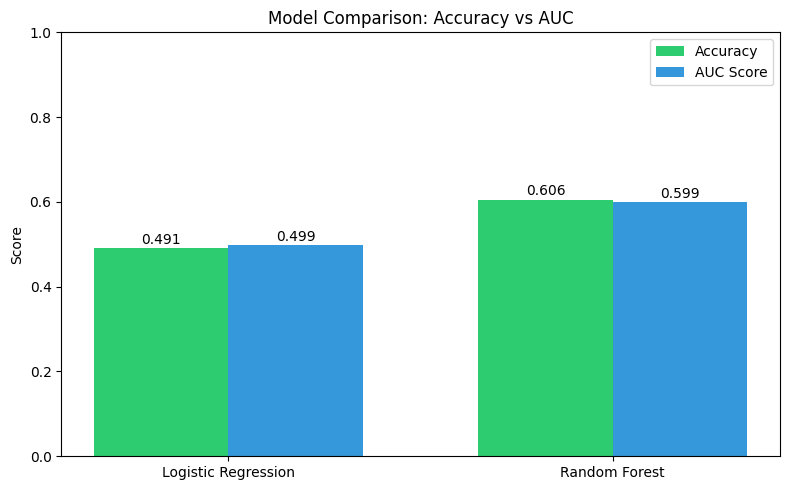

In [5]:
models = ['Logistic Regression', 'Random Forest']
accuracies = [lr_acc, rf_acc]
aucs = [lr_auc, rf_auc]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='#2ecc71')
bars2 = ax.bar(x + width/2, aucs, width, label='AUC Score', color='#3498db')

ax.set_ylabel('Score')
ax.set_title('Model Comparison: Accuracy vs AUC')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/visualizations/model_comparison.png', dpi=150)
plt.show()

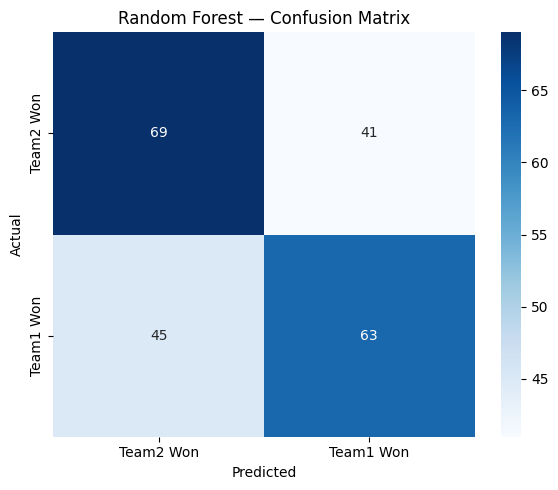

In [6]:
# Use Random Forest as our best model
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Team2 Won', 'Team1 Won'],
            yticklabels=['Team2 Won', 'Team1 Won'])
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../reports/visualizations/confusion_matrix.png', dpi=150)
plt.show()

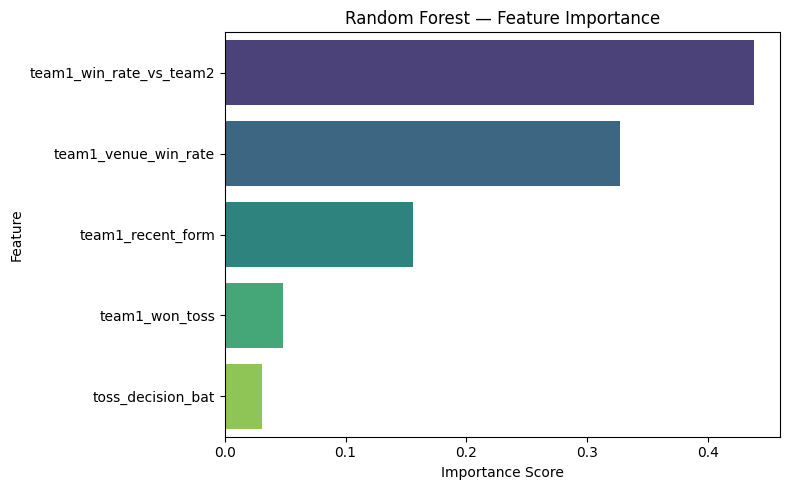

                   feature  importance
0  team1_win_rate_vs_team2    0.437920
3     team1_venue_win_rate    0.327363
4        team1_recent_form    0.155839
1           team1_won_toss    0.047979
2        toss_decision_bat    0.030899


In [7]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance, x='importance', y='feature',
            hue='feature', palette='viridis', legend=False)
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../reports/visualizations/feature_importance.png', dpi=150)
plt.show()

print(importance)

In [8]:
import pickle

# Save models
with open('../models/logistic_regression.pkl', 'wb') as f:
    pickle.dump(lr, f)

with open('../models/random_forest.pkl', 'wb') as f:
    pickle.dump(rf, f)

# Save metrics
metrics = {
    'logistic_regression': {'accuracy': round(lr_acc, 3), 'auc': round(lr_auc, 3)},
    'random_forest':       {'accuracy': round(rf_acc, 3), 'auc': round(rf_auc, 3)}
}
with open('../models/model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("Models and metrics saved!")
print(json.dumps(metrics, indent=2))

Models and metrics saved!
{
  "logistic_regression": {
    "accuracy": 0.491,
    "auc": 0.499
  },
  "random_forest": {
    "accuracy": 0.606,
    "auc": 0.599
  }
}
